In [2]:
!pip install torch

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)


In [4]:
!pip install ultralytics

  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 6.2 MB/s  0:00:00
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 824.0/824.0 kB 16.2 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
   ---- ----------------------------------- 5.0/47.0 MB 23.6 MB/s eta 0:00:02
   ---------- ----------------------------- 11.8/47.0 MB 27.7 MB/s eta 0:00:02
   ---------------- ----------------------- 18.9/47.0 MB 29.7 MB/s eta 0:00:01
   --------------------- ------------------ 25.7/47.0 MB 30.5 MB/s eta 0:00:01
   -------------------------- ------------- 31.7/47.0 MB 29.7 MB/s eta 0:00:01
   ------------------------------- -------- 37.2/47.0 MB 29.0 MB/s eta 0:00:01
   --------------

In [2]:
import sys
print(sys.executable)

D:\5th_sem\Anaconda\envs\SUJANEV1\python.exe


In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

In [1]:
from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")

model.train(
    data="E:/new_folder/data.yaml",
    epochs=50,
    imgsz=640,
    batch=2,
    device=0  
)

Ultralytics 8.4.37  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:/new_folder/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train21, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000022E8B63D400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [9]:
from ultralytics import YOLO

model = YOLO("C:/Users/SUJAN K S/runs/segment/train21/weights/best.pt")

In [31]:
from ultralytics import YOLO
import pandas as pd
from IPython.display import display

model = YOLO("C:/Users/SUJAN K S/runs/segment/train21/weights/best.pt")

metrics = model.val()

data = {
    "Metric": ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"],
    "Value": [
        round(metrics.box.mp, 3),
        round(metrics.box.mr, 3),
        round(metrics.box.map50, 3),
        round(metrics.box.map, 3)
    ]
}

df = pd.DataFrame(data)

styled_df = df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '14px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f2f2f2'),
                                ('font-weight', 'bold')]}
])

display(HTML("<h2>📊 Model Performance Metrics</h2>"))
display(styled_df)

Ultralytics 8.4.37  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 342.640.8 MB/s, size: 56.9 KB)
val: Scanning E:\new_folder\valid\labels.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 19.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0s/it 5.0s1.1ss
                   all         70         81      0.843      0.802      0.837      0.448      0.844      0.679      0.731      0.342
Speed: 3.1ms preprocess, 21.2ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to C:\Users\SUJAN K S\runs\segment\val7


,Metric,Value
0,Precision,0.843000
1,Recall,0.802000
2,mAP@0.5,0.837000
3,mAP@0.5:0.95,0.448000


In [37]:
%matplotlib inline

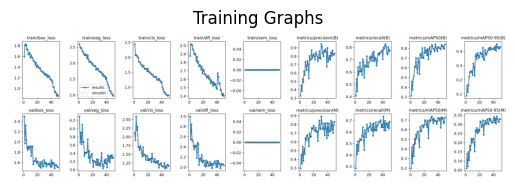

In [50]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("C:/Users/SUJAN K S/runs/segment/train21/results.png")

plt.imshow(img)
plt.axis("off")
plt.title("Training Graphs")
plt.show()

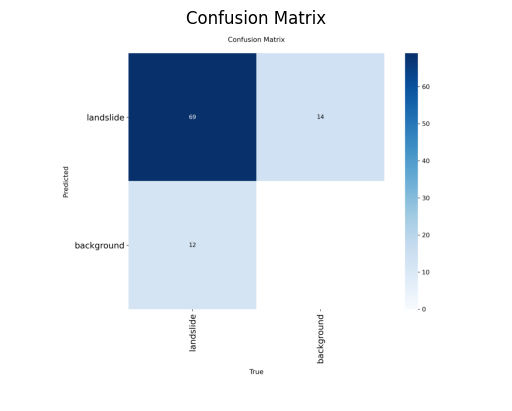

In [49]:
img = mpimg.imread("C:/Users/SUJAN K S/runs/segment/val2/confusion_matrix.png")

plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

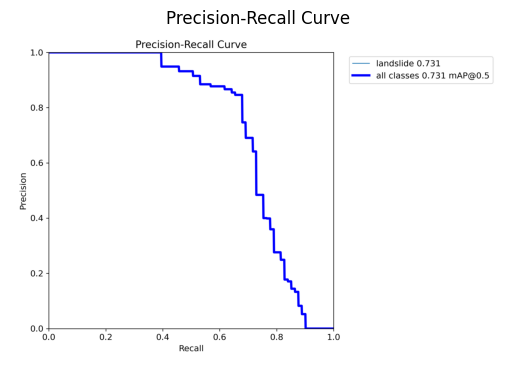

In [48]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

path = "C:/Users/SUJAN K S/runs/segment/val2/MaskPR_curve.png"

img = mpimg.imread(path)

plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve")
plt.show()

Showing: BoxF1_curve.png


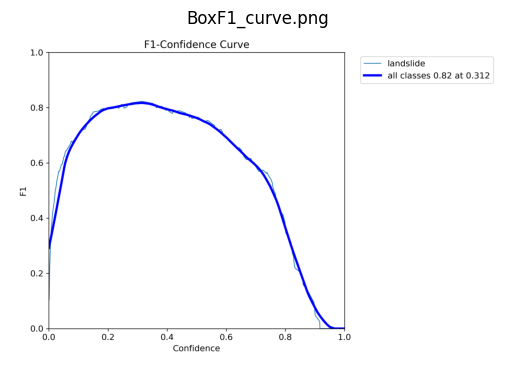

Showing: BoxPR_curve.png


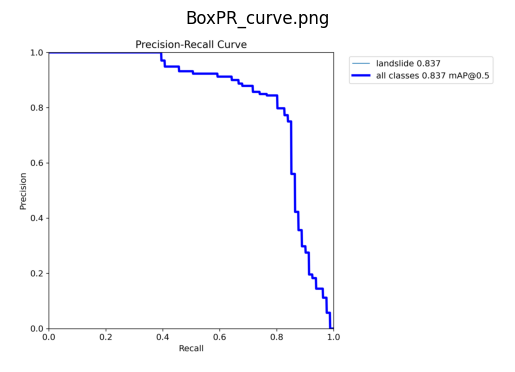

Showing: BoxP_curve.png


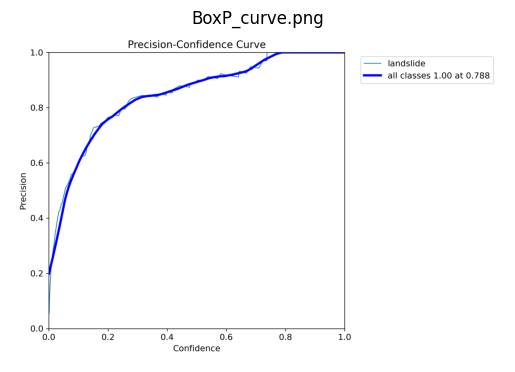

Showing: BoxR_curve.png


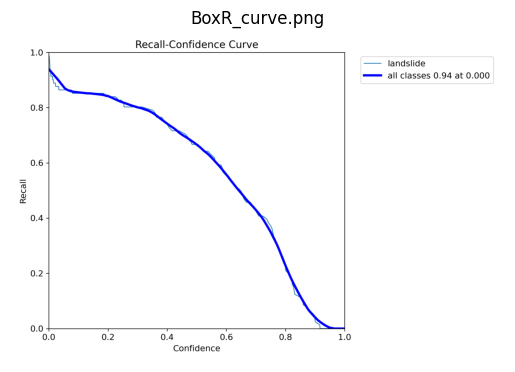

Showing: confusion_matrix.png


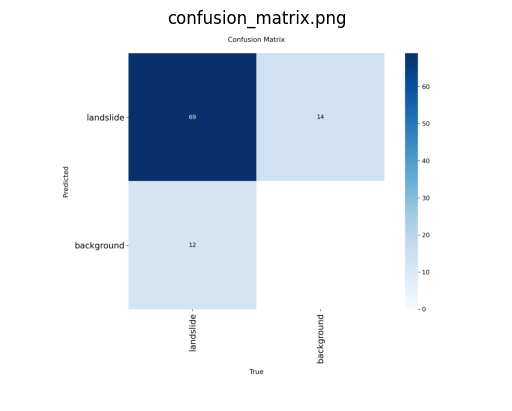

Showing: confusion_matrix_normalized.png


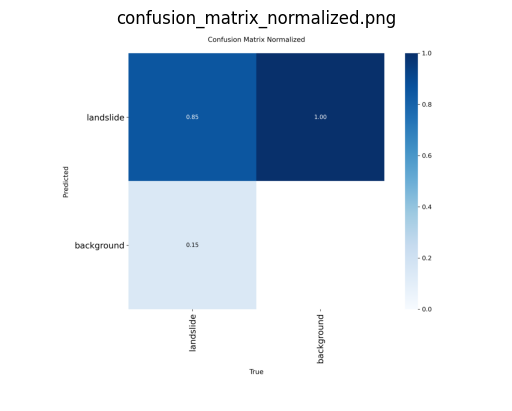

Showing: MaskF1_curve.png


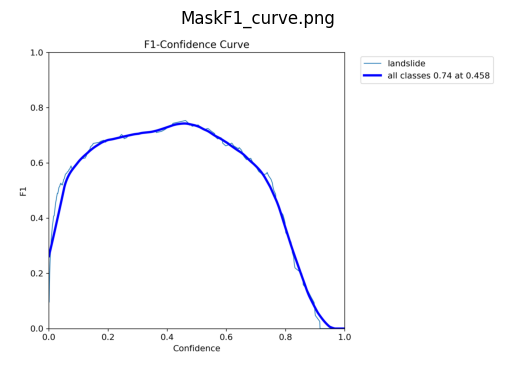

Showing: MaskPR_curve.png


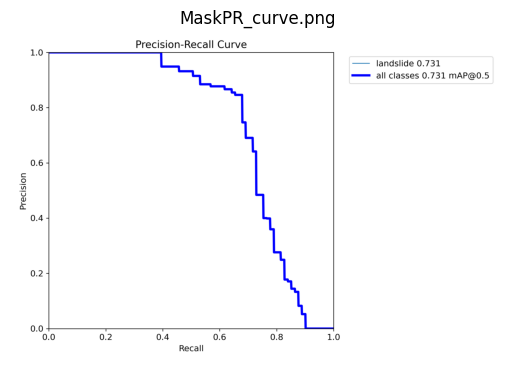

Showing: MaskP_curve.png


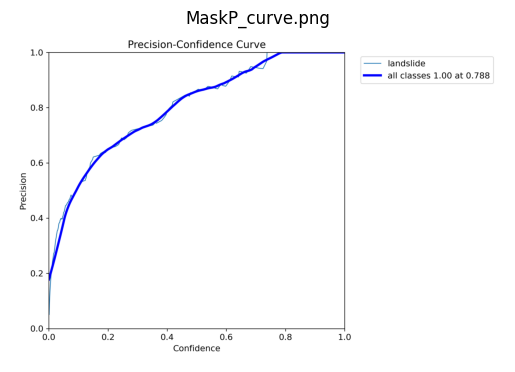

Showing: MaskR_curve.png


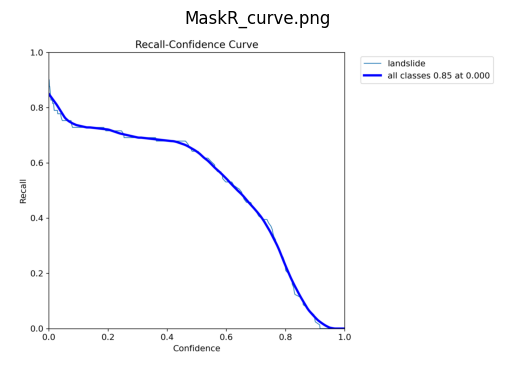

In [45]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

folder = "C:/Users/SUJAN K S/runs/segment/val2"

for file in os.listdir(folder):
    if file.endswith(".png"):
        print("Showing:", file)
        
        img = mpimg.imread(f"{folder}/{file}")
        plt.imshow(img)
        plt.title(file)
        plt.axis("off")
        plt.show()

In [17]:
from ultralytics import YOLO

model = YOLO("C:/Users/SUJAN K S/runs/segment/train21/weights/best.pt")

metrics = model.val()

Ultralytics 8.4.37  Python-3.13.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 419.578.3 MB/s, size: 68.0 KB)
val: Scanning E:\new_folder\valid\labels.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 21.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2s/it 5.8s1.2s1s
                   all         70         81      0.843      0.802      0.837      0.448      0.844      0.679      0.731      0.342
Speed: 4.2ms preprocess, 22.8ms inference, 0.0ms loss, 7.6ms postprocess per image
Results saved to C:\Users\SUJAN K S\runs\segment\val2


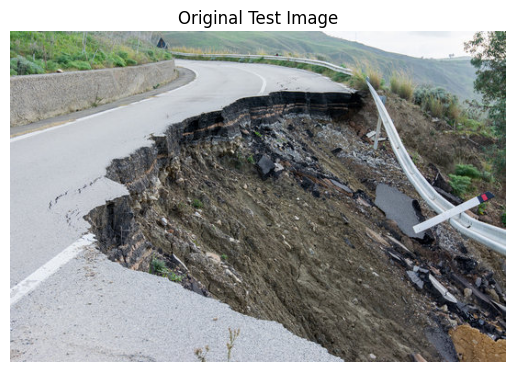

In [53]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("suimage.jpg")

plt.imshow(img)
plt.title("Original Test Image")
plt.axis("off")
plt.show()

In [59]:
from ultralytics import YOLO

model = YOLO("C:/Users/SUJAN K S/runs/segment/train21/weights/best.pt")

results = model.predict(
    source="suimage.jpg",
    save=True,
    conf=0.5
)


image 1/1 C:\Users\SUJAN K S\suimage.jpg: 448x640 1 landslide, 89.3ms
Speed: 3.3ms preprocess, 89.3ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\SUJAN K S\runs\segment\predict7


In [60]:
import os
print(os.listdir("runs/segment/predict"))

['suimage.jpg']


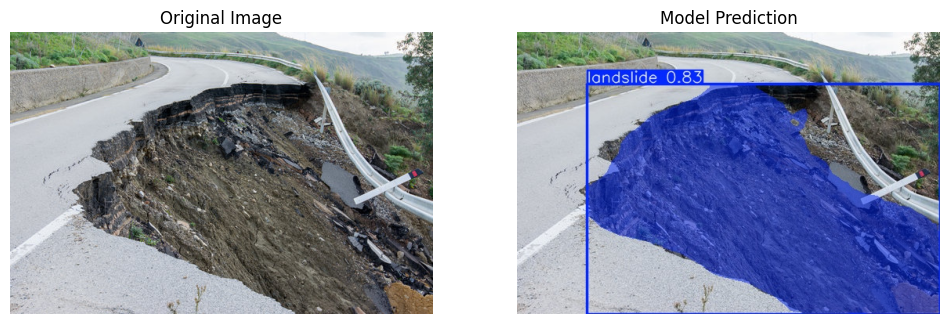

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))

# Original
img1 = mpimg.imread("suimage.jpg")
axs[0].imshow(img1)
axs[0].set_title("Original Image")
axs[0].axis("off")

img2 = mpimg.imread("runs/segment/predict7/suimage.jpg")
axs[1].imshow(img2)
axs[1].set_title("Model Prediction")
axs[1].axis("off")

plt.show()

In [64]:
from ultralytics import YOLO

model = YOLO("C:/Users/SUJAN K S/runs/segment/train21/weights/best.pt")

results = model.predict(
    source="suimage1.jpg",
    save=True,
    conf=0.5
)


image 1/1 C:\Users\SUJAN K S\suimage1.jpg: 384x640 (no detections), 21.5ms
Speed: 3.5ms preprocess, 21.5ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\SUJAN K S\runs\segment\predict9


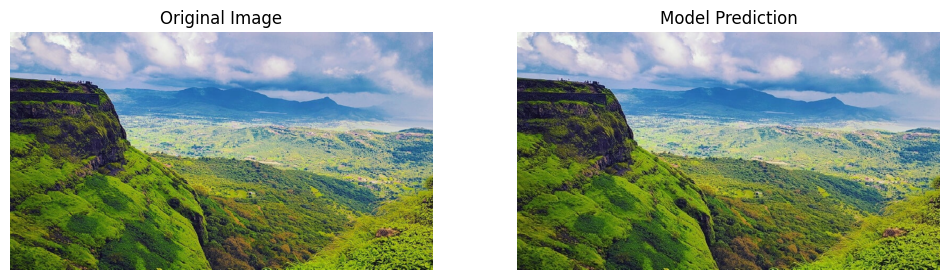

In [65]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axs = plt.subplots(1, 2, figsize=(12,6))

# Original
img1 = mpimg.imread("suimage1.jpg")
axs[0].imshow(img1)
axs[0].set_title("Original Image")
axs[0].axis("off")

# Prediction
img2 = mpimg.imread("runs/segment/predict9/suimage1.jpg")
axs[1].imshow(img2)
axs[1].set_title("Model Prediction")
axs[1].axis("off")

plt.show()